In [171]:
from tensorflow.keras.datasets import imdb
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

import random
import re
import os
import numpy as np
import matplotlib.pyplot as plt

SEED = 209

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


## data loading

In [149]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

## data preproccessing

In [150]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, np.unique(y_train)

((25000,), (25000,), (25000,), (25000,), array([0, 1]))

In [151]:
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)
y_train.shape

(25000, 1)

In [152]:
len(X_train[0]), len(X_train[1])

(218, 189)

In [153]:
lengths = [len(x) for x in X_train]
print("Max length:", max(lengths))
print("Min length:", min(lengths))
print("Average length:", int(np.mean(lengths)))
print("Median length:", int(np.median(lengths)))

Max length: 2494
Min length: 11
Average length: 238
Median length: 178


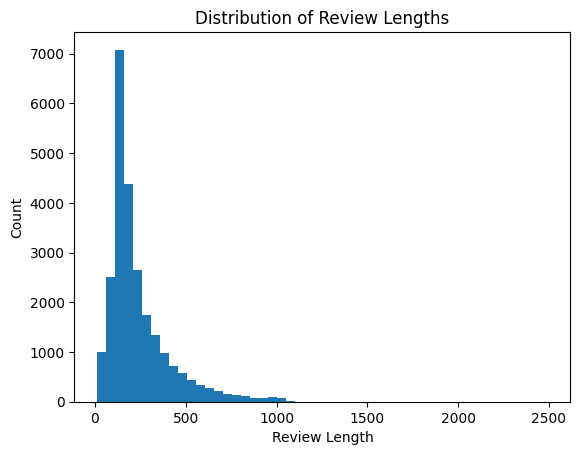

In [154]:
plt.hist(lengths, bins=50)
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.title("Distribution of Review Lengths")
plt.show()

In [155]:
max_length = 350
X_train_pad = pad_sequences(X_train, maxlen=max_length)
X_test_pad = pad_sequences(X_test, maxlen=max_length)

In [156]:
X_train_pad.shape, X_test_pad.shape

((25000, 350), (25000, 350))

## Modeling Implement and comparing

In [157]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)
file_name = "_best_model"

### Simple RNN

In [158]:
embbeding_size = 128
hidden_state_size = 32
dropout = 0.4

In [159]:
model_rnn = Sequential([
    Embedding(vocab_size, embbeding_size),
    SimpleRNN(hidden_state_size, dropout=dropout),
    Dropout(dropout),
    Dense(1, activation='sigmoid')
])
model_rnn.build(input_shape=(None, max_length))
model_rnn.summary()
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ (None, 350, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,185 (4.90 MB)

 Trainable params: 1,285,185 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [160]:
checkpoint_rnn = ModelCheckpoint(
    filepath=f'rnn{file_name}.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint_rnn]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5939 - loss: 0.6639
Epoch 1: val_accuracy improved from -inf to 0.74920, saving model to rnn_best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.5940 - loss: 0.6638 - val_accuracy: 0.7492 - val_loss: 0.5257
Epoch 2/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8139 - loss: 0.4391
Epoch 2: val_accuracy did not improve from 0.74920
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8139 - loss: 0.4391 - val_accuracy: 0.7276 - val_loss: 0.5375
Epoch 3/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8498 - loss: 0.3678
Epoch 3: val_accuracy improved from 0.74920 to 0.81800, saving model to rnn_best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8499 - loss: 0.3676 - val_accuracy: 0.8180 - val_loss: 0.4338
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9129 - loss: 0.2348
Epoch 4: val_accuracy improved from 0.81800 to 0.82800, saving 

#### **RNN obseravations**
1. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.4** ==> train acc: 97.6%, val acc: 82.3% then drops (overfitting)
2. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.2** ==> train acc: 98.6%, val acc: 81.7% then drops (overfitting).
   * Increasing dropout from 0.2 to 0.4 slightly reduced overfitting (train/val gap narrowed) but did not improve val accuracy, confirming the bottleneck is the architecture not regularization.


3. **embedding_size: 64**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 81.5%, val acc: 81.4%.
   * reduced memorization and closing the train/val gap significantly.
     
4. **embedding_size: 128**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 87.9%, val acc: 84.6%. *(best one)*
   * Best RNN configuration — larger embeddings provided richer word representations, reducing memorization and closing the train/val gap significantly.
  
5. embedding_size: 128, **hidden_state_size: 64**, dropout: 0.4 ==> train acc: 86.5%, val acc: 84.6%.
   * not realy big change

### LSTM

In [161]:
embbeding_size = 128
hidden_state_size = 32 
dropout = 0.4

In [162]:
model_lstm = Sequential([
    Embedding(vocab_size, embbeding_size),
    LSTM(hidden_state_size, dropout=dropout),
    Dropout(dropout),
    Dense(1, activation='sigmoid')
])
model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 350, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,300,641 (4.96 MB)

 Trainable params: 1,300,641 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

In [163]:
checkpoint_lstm = ModelCheckpoint(
    filepath=f'lstm{file_name}.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint_lstm]
)

Epoch 1/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6971 - loss: 0.5649
Epoch 1: val_accuracy improved from -inf to 0.86300, saving model to lstm_best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6976 - loss: 0.5643 - val_accuracy: 0.8630 - val_loss: 0.3532
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8883 - loss: 0.2925
Epoch 2: val_accuracy improved from 0.86300 to 0.87820, saving model to lstm_best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8883 - loss: 0.2924 - val_accuracy: 0.8782 - val_loss: 0.3009
Epoch 3/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9180 - loss: 0.2217
Epoch 3: val_accuracy did not improve from 0.87820
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9180 - loss: 0.2217 - val_accuracy: 0.8760 - val_loss: 0.3329
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9299 - loss: 0.1901
Epoch 4: val_accuracy did not improve from 0.87820
313/313 ━━━

#### **LSTM obseravations**

1. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.4** ==> train acc: 94.8%, val acc: 88.3% then platues

2. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.2** ==> train acc: 92.7%, val acc: 87.4% then platues

3. **embbeding_size: 64**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 92.5%, val acc: 88.3%

4. **embbeding_size: 128**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 91.3%, val acc: 88.2% *(best one)*
   * embbeding size slightly reduced the train val gap by decreasing the training acc

5.  embbeding_size: 128, **hidden_state_size: 64**, dropout: 0.4 ==> train acc: 90.9%, val acc: 87.6%
    * hidden_state_size reduced the train val gap by decreasing the training acc(more genaralized results)


### GRU

In [164]:
embbeding_size = 64
hidden_state_size = 32
dropout = 0.4

In [165]:
model_gru = Sequential([
    Embedding(vocab_size, embbeding_size),
    GRU(hidden_state_size, dropout=dropout),
    Dropout(dropout),
    Dense(1, activation='sigmoid')
])
model_gru.build(input_shape=(None, max_length))
model_gru.summary()
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, 350, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,441 (2.48 MB)

 Trainable params: 649,441 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [166]:
checkpoint_gru = ModelCheckpoint(
    filepath=f'gru{file_name}.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_gru = model_lstm.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint_gru]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9191 - loss: 0.2195
Epoch 1: val_accuracy improved from -inf to 0.87840, saving model to gru_best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9191 - loss: 0.2195 - val_accuracy: 0.8784 - val_loss: 0.3082
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9349 - loss: 0.1811
Epoch 2: val_accuracy did not improve from 0.87840
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9349 - loss: 0.1811 - val_accuracy: 0.8462 - val_loss: 0.4507
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9419 - loss: 0.1649
Epoch 3: val_accuracy did not improve from 0.87840
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9419 - loss: 0.1649 - val_accuracy: 0.8738 - val_loss: 0.3670
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9206 - loss: 0.2068
Epoch 4: val_accuracy did not improve from 0.87840
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0

#### **GRU obseravations**
1. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.4** ==> train acc: 96.6%, val acc: 87.8% then drops then drops mildly (overfitting)
2. embbeding_size: 32, hidden_state_size: 32, **dropout: 0.2** ==> train acc: 94.7%, val acc: 87.9% after epoch 1 then drops mildly (small overfitting)
3. **embbeding_size: 64**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 95.6%, val acc: 88.1% *(best one)*
   * reduced the train val gap by increasing the val and decreasing the training
4. **embbeding_size: 128**, hidden_state_size: 32, dropout: 0.4 ==> train acc: 95.1%, val acc: 87.6%
   * almost the same as 64 

5.  embbeding_size: 128, **hidden_state_size: 64**, dropout: 0.4 ==> train acc: 95%, val acc: 86.6%
    * slightly increased the gap (almost no effect)

## Evaluation and analysis

In [167]:
best_rnn = load_model('rnn_best_model.keras')
best_lstm = load_model('lstm_best_model.keras')
best_gru = load_model('gru_best_model.keras')

In [168]:
# Best RNN
y_pred_rnn = (best_rnn.predict(X_test_pad) > 0.5).astype(int)
print("RNN:")
print(classification_report(y_test, y_pred_rnn))

# Best LSTM
y_pred_lstm = (best_lstm.predict(X_test_pad) > 0.5).astype(int)
print("LSTM:")
print(classification_report(y_test, y_pred_lstm))

# Best GRU
y_pred_gru = (best_gru.predict(X_test_pad) > 0.5).astype(int)
print("GRU:")
print(classification_report(y_test, y_pred_gru))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
RNN:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     12500
           1       0.81      0.84      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
LSTM:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87     12500
           1       0.85      0.90      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
GRU:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87     12500
           1       0.86      0.89      0.87     12500

    accuracy                           0.87

| Model | Test Accuracy | F1 (neg) | F1 (pos) | Macro F1 |
|-------|---------------|----------|----------|----------|
| SimpleRNN | 82% | 82% | 83% | 82.5% |
| LSTM | 87% | 87% | 87% | 87% |
| GRU | 87% | 87% | 87% | 87% |

`GRU` and `LSTM` have the same performance but `GRU` is more simple so in this case `GRU` is the best model

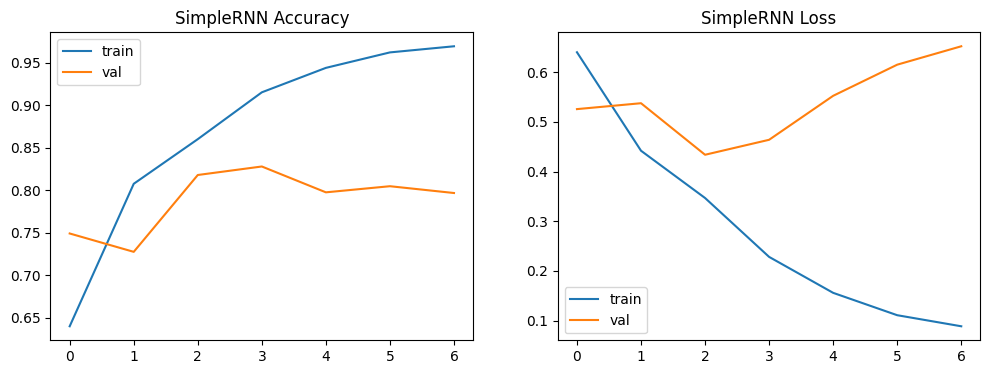

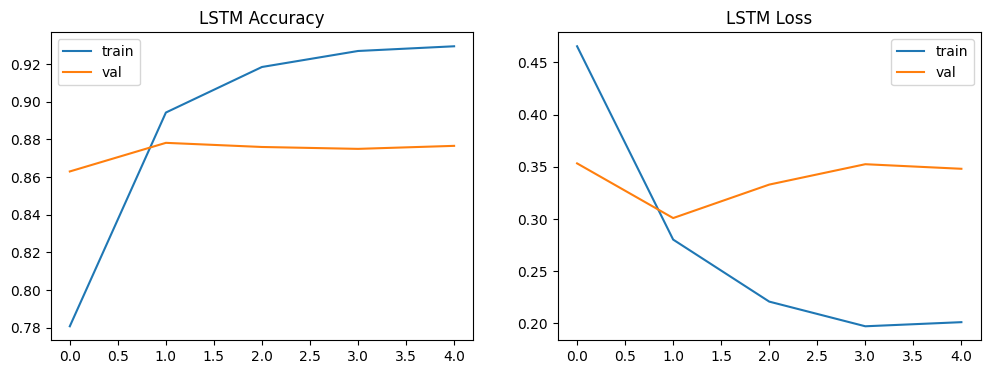

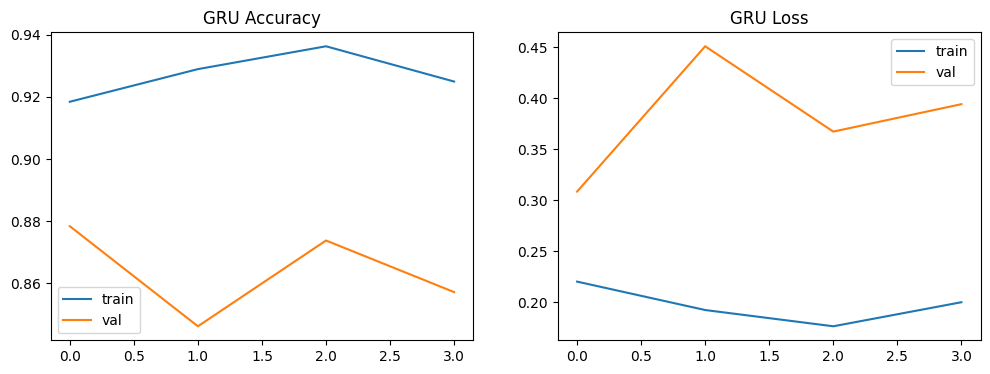

In [216]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

plot_history(history_rnn, 'SimpleRNN')
plot_history(history_lstm, 'LSTM')
plot_history(history_gru, 'GRU')

## Prediction Demo

In [210]:
word_index = imdb.get_word_index()

def clean_text(reviews: list[str]) -> list[list[str]]:
    reviews = [r.lower() for r in reviews]
    reviews = [re.sub(r'[^a-z\s-]', ' ', r) for r in reviews]
    reviews = [re.sub(r'\s+', ' ', r) for r in reviews]
    return [r.split() for r in reviews]

def encode_review(reviews: list[str]) -> list[list[int]]:

    reviews = clean_text(reviews)
    encoded = [[word_index.get(word, 2) + 3 for word in review] for review in reviews]
    
    # 3. pad to max_length
    padded = pad_sequences(encoded, maxlen=max_length, padding='pre', truncating='pre')
    
    return padded

def predict_sentiment(review, model):
    x = encode_review(review)
    y_pred = model.predict(x, verbose=0)
    for y in y_pred:
        p = y[0]
        sentiment = "Positive" if p > 0.5 else "Negative"
        confidence = p if p > 0.5 else 1 - p
        print(f"Sentiment: {sentiment} (confidence: {confidence:.1%})")
    

In [215]:
reviews = ["Holy hell what a ride, this movie destroyed me in the best way",
           "it was a horrible movie",
           "Oh great, another two hours of my life I'll never get back",
           "The acting was brilliant but the story was completely pointless",
           "What the hell, this movie actually blew my mind"]

predict_sentiment(reviews, best_lstm)

Sentiment: Positive (confidence: 82.6%)
Sentiment: Negative (confidence: 78.8%)
Sentiment: Negative (confidence: 54.4%)
Sentiment: Negative (confidence: 82.2%)
Sentiment: Positive (confidence: 65.0%)
